# Sentiment Analysis
measuring how reddit sentiment about AI and wikipedia has shifted over time, using roberta as the primary model and vader as a sanity check baseline (roberta is a more advanced model that can capture more context than vader).

hypothesis: sentiment became more negative after chatgpt launched (nov 30, 2022) as concerns about AI-generated content on wikipedia grew.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('../..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

from src.sentiment import (
    vader_sentiment,
    roberta_sentiment,
    flag_sentiment_quality,
    compute_agreement,
    get_disagreement_summary,
    aggregate_sentiment_by_month
)
from src.data_prep import add_pre_post_chatgpt

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (13, 5)
plt.rcParams['figure.dpi'] = 100

os.makedirs('../../data/processed/reddit_processed', exist_ok=True)
os.makedirs('../../reports/reddit_reports', exist_ok=True)

CHATGPT_LAUNCH = pd.Timestamp('2022-11-30')
COLORS = {
    'positive': '#2196F3',
    'neutral':  '#90A4AE',
    'negative': '#F44336',
    'pre':      '#90CAF9',
    'post':     '#1565C0',
}

In [2]:
df = pd.read_csv(
    '../../data/raw/reddit_raw/reddit_ai_wikipedia_posts.csv',
    parse_dates=['date']
)

df = add_pre_post_chatgpt(df, date_col='date')

# make sure combined_text exists and is clean
if 'combined_text' not in df.columns:
    df['combined_text'] = df['title'].fillna('') + ' ' + df['text'].fillna('')
df['combined_text'] = df['combined_text'].str.strip()

print(f'loaded {len(df)} posts')
print(f'date range: {df["date"].min().strftime("%Y-%m-%d")} to {df["date"].max().strftime("%Y-%m-%d")}')
print(f'pre-ChatGPT: {(df["period"]=="pre-ChatGPT").sum()} | post-ChatGPT: {(df["period"]=="post-ChatGPT").sum()}')
print(f'subreddits: {df["subreddit"].unique()}')
print(f'posts with body text: {df["text"].notna().sum()} ({df["text"].notna().mean()*100:.1f}%)')

loaded 1591 posts
date range: 2020-01-02 to 2026-03-04
pre-ChatGPT: 293 | post-ChatGPT: 1298
subreddits: ['technology' 'wikipedia' 'ChatGPT' 'MachineLearning' 'OpenAI'
 'singularity' 'artificial']
posts with body text: 1204 (75.7%)


## VADER Baseline
vader is rule-based, runs in under a second, and gives us something to compare roberta against. it's known to overcount positives on reddit because it treats capitalisation, exclamation marks, and emoji-adjacent punctuation as positive signals.

In [3]:
df = vader_sentiment(df, text_col='combined_text')

print('VADER label distribution:')
print(df['vader_label'].value_counts())
print(f'\nmean compound score: {df["vader_compound"].mean():.3f}')
print(f'pre-ChatGPT mean:  {df[df["period"]=="pre-ChatGPT"]["vader_compound"].mean():.3f}')
print(f'post-ChatGPT mean: {df[df["period"]=="post-ChatGPT"]["vader_compound"].mean():.3f}')

VADER label distribution:
vader_label
positive    1035
negative     320
neutral      236
Name: count, dtype: int64

mean compound score: 0.390
pre-ChatGPT mean:  0.582
post-ChatGPT mean: 0.347


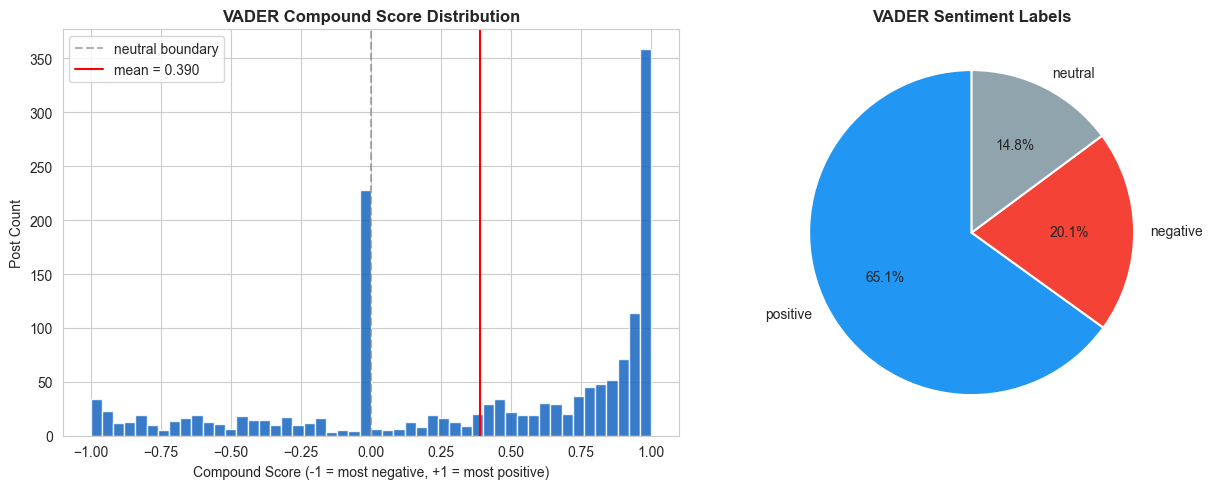

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# distribution of compound scores
ax = axes[0]
ax.hist(df['vader_compound'], bins=50, color='#1565C0', edgecolor='white', alpha=0.85)
ax.axvline(0, color='gray', linestyle='--', alpha=0.6, label='neutral boundary')
ax.axvline(df['vader_compound'].mean(), color='red', linestyle='-', linewidth=1.5, label=f'mean = {df["vader_compound"].mean():.3f}')
ax.set_title('VADER Compound Score Distribution', fontsize=12, fontweight='bold')
ax.set_xlabel('Compound Score (-1 = most negative, +1 = most positive)')
ax.set_ylabel('Post Count')
ax.legend()

# label breakdown as a pie
ax = axes[1]
counts = df['vader_label'].value_counts()
colors = [COLORS[l] for l in counts.index]
ax.pie(counts, labels=counts.index, autopct='%1.1f%%', colors=colors,
       startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
ax.set_title('VADER Sentiment Labels', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('../../reports/reddit_reports/vader_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## RoBERTa Sentiment
using `cardiffnlp/twitter-roberta-base-sentiment-latest`, which was trained on ~124 million tweets. it understands social media language, sarcasm, and context much better than a rule-based system.

i request scores for all 3 classes (`top_k=None`) instead of just the top-1 prediction. this gives us a continuous weighted score (positive_prob - negative_prob) which is far more informative for trend analysis than averaging -1/0/1 labels.

In [5]:
print('running roberta sentiment analysis...')
df = roberta_sentiment(df, text_col='combined_text', batch_size=32)

print('\nRoBERTa label distribution:')
print(df['roberta_label'].value_counts())
print(f'\nmean continuous score: {df["roberta_continuous"].mean():.3f}')
print(f'mean confidence (roberta_score): {df["roberta_score"].mean():.3f}')

running roberta sentiment analysis...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.pooler.dense.bias       | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 
roberta.pooler.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  done. 1591 posts scored.          

RoBERTa label distribution:
roberta_label
neutral     1051
negative     334
positive     206
Name: count, dtype: int64

mean continuous score: -0.043
mean confidence (roberta_score): 0.731


In [6]:
# add quality flags and agreement columns
df = flag_sentiment_quality(df, confidence_threshold=0.65)
df = compute_agreement(df)

print(f'high-confidence predictions (score >= 0.65): {df["high_confidence"].sum()} ({df["high_confidence"].mean()*100:.1f}%)')
print(f'posts with body text: {df["has_body"].sum()} ({df["has_body"].mean()*100:.1f}%)')

high-confidence predictions (score >= 0.65): 1123 (70.6%)
posts with body text: 1201 (75.5%)


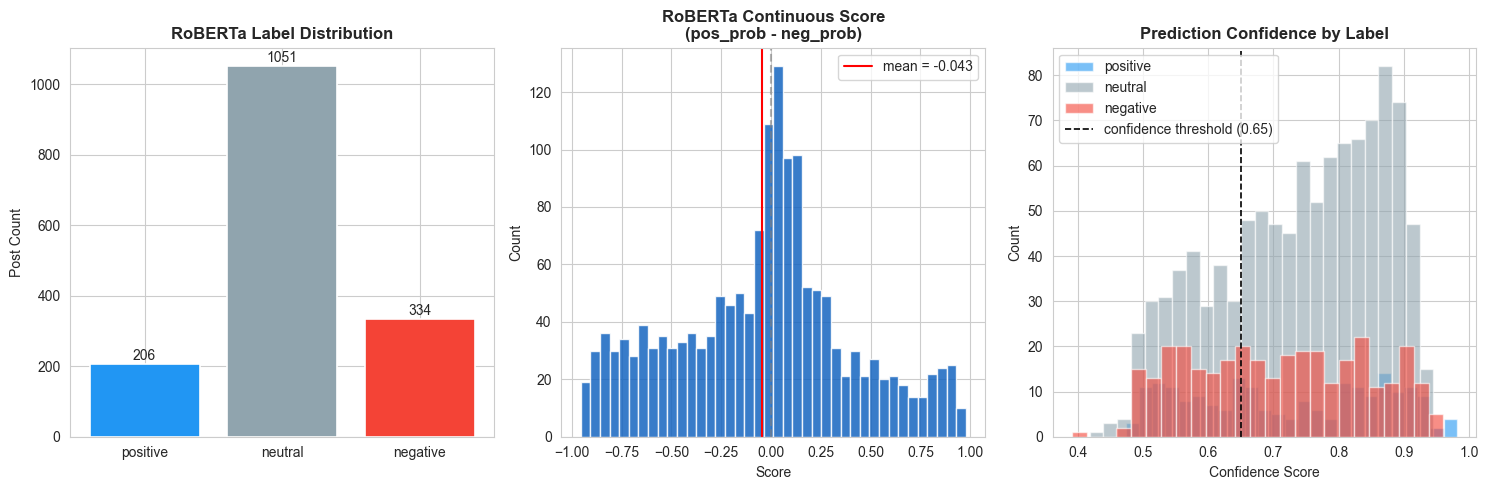

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# label distribution
ax = axes[0]
counts = df['roberta_label'].value_counts().reindex(['positive','neutral','negative'])
bars = ax.bar(counts.index, counts.values,
              color=[COLORS[l] for l in counts.index],
              edgecolor='white', linewidth=1.2)
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
            str(val), ha='center', va='bottom', fontsize=10)
ax.set_title('RoBERTa Label Distribution', fontsize=12, fontweight='bold')
ax.set_ylabel('Post Count')

# continuous score distribution
ax = axes[1]
ax.hist(df['roberta_continuous'], bins=40, color='#1565C0', edgecolor='white', alpha=0.85)
ax.axvline(0, color='gray', linestyle='--', alpha=0.6)
ax.axvline(df['roberta_continuous'].mean(), color='red', linewidth=1.5,
           label=f'mean = {df["roberta_continuous"].mean():.3f}')
ax.set_title('RoBERTa Continuous Score\n(pos_prob - neg_prob)', fontsize=12, fontweight='bold')
ax.set_xlabel('Score')
ax.set_ylabel('Count')
ax.legend()

# confidence score distribution by label
ax = axes[2]
for label in ['positive', 'neutral', 'negative']:
    subset = df[df['roberta_label'] == label]['roberta_score']
    ax.hist(subset, bins=25, alpha=0.6, label=label, color=COLORS[label])
ax.axvline(0.65, color='black', linestyle='--', linewidth=1.2, label='confidence threshold (0.65)')
ax.set_title('Prediction Confidence by Label', fontsize=12, fontweight='bold')
ax.set_xlabel('Confidence Score')
ax.set_ylabel('Count')
ax.legend()

plt.tight_layout()
plt.savefig('../../reports/reddit_reports/roberta_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## VADER vs RoBERTa Disagreement Analysis
these two models only agree on about 40% of posts, which sounds bad but actually makes sense. the disagreement is almost entirely in one direction: vader calls things *positive* that roberta calls *neutral*. this is the classic vader problem on reddit, where short enthusiastic titles (capitalisation, exclamation marks, conversational positivity) get inflated compound scores even when the actual sentiment is just informational.

conclusion: roberta is the primary model for all analysis. vader scores are kept as a secondary reference.

In [8]:
breakdown = get_disagreement_summary(df)

agreement rate: 537/1591 = 33.8%
disagreement breakdown:
vader_label roberta_label  count  pct_of_total
   positive       neutral    717          45.1
   negative       neutral    143           9.0
   positive      negative    139           8.7
    neutral      negative     28           1.8
    neutral      positive     17           1.1
   negative      positive     10           0.6


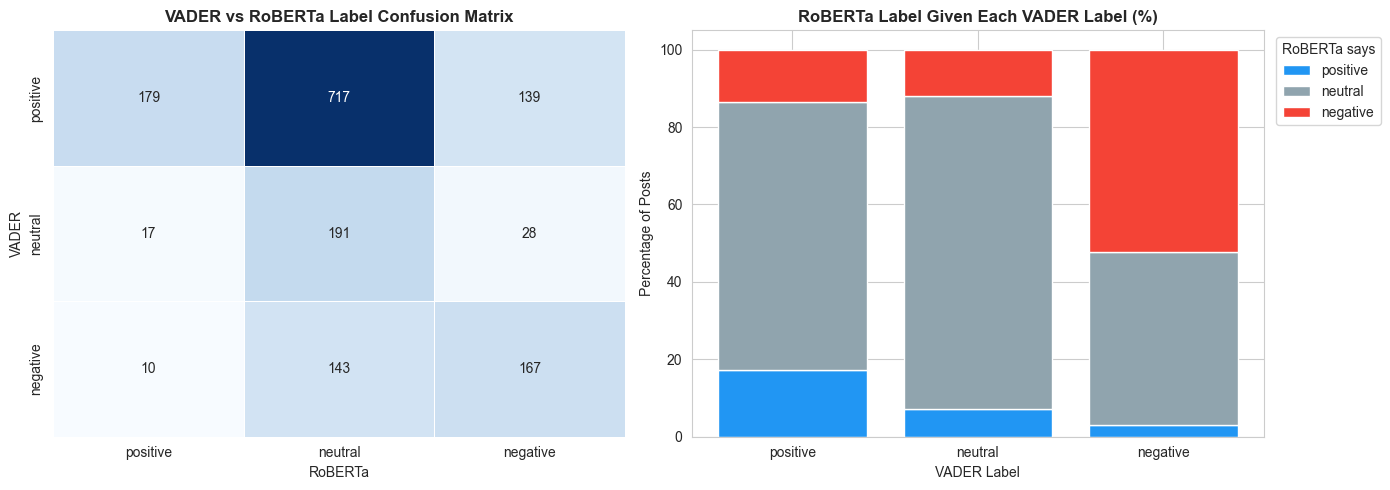

sample posts where vader=positive but roberta=negative:
  [vader=0.25] [roberta_conf=0.52] Wikipedia Is Getting Pretty Worried About AI
  [vader=0.22] [roberta_conf=0.53] ChatGPT really wants to slap Elon Musk.
  [vader=0.67] [roberta_conf=0.72] Sorry, You Don't Actually Know the Pain is Fake
  [vader=0.54] [roberta_conf=0.60] OpenAI are now stealth routing all o3 requests to GPT-5
  [vader=0.64] [roberta_conf=0.66] Can someone help me understand the existence of an article like this? It appears to have b
  [vader=0.96] [roberta_conf=0.74] Why are so many people luddites about AI?
  [vader=0.42] [roberta_conf=0.62] In machine learning, a "stochastic parrot" is a large language model that is good at gener
  [vader=0.85] [roberta_conf=0.64] amusing scam
  [vader=0.84] [roberta_conf=0.67] AI hallucinations are getting scary good at sounding real what's your strategy :
  [vader=0.46] [roberta_conf=0.87] It’s reached google image search


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# confusion matrix heatmap
ax = axes[0]
label_order = ['positive', 'neutral', 'negative']
confusion = pd.crosstab(
    df['vader_label'], df['roberta_label'],
    rownames=['VADER'], colnames=['RoBERTa']
).reindex(index=label_order, columns=label_order, fill_value=0)
sns.heatmap(confusion, annot=True, fmt='d', cmap='Blues', ax=ax,
            linewidths=0.5, linecolor='white', cbar=False)
ax.set_title('VADER vs RoBERTa Label Confusion Matrix', fontsize=12, fontweight='bold')

# stacked bar: for each vader label, what does roberta say?
ax = axes[1]
cross = pd.crosstab(df['vader_label'], df['roberta_label'], normalize='index') * 100
cross = cross.reindex(index=label_order, columns=label_order, fill_value=0)
bottom = np.zeros(len(cross))
for label in label_order:
    vals = cross[label].values
    ax.bar(cross.index, vals, bottom=bottom, label=label, color=COLORS[label], edgecolor='white')
    bottom += vals
ax.set_title('RoBERTa Label Given Each VADER Label (%)', fontsize=12, fontweight='bold')
ax.set_xlabel('VADER Label')
ax.set_ylabel('Percentage of Posts')
ax.legend(title='RoBERTa says', bbox_to_anchor=(1.01, 1), loc='upper left')

plt.tight_layout()
plt.savefig('../../reports/reddit_reports/vader_roberta_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# sample posts where they strongly disagree
print('sample posts where vader=positive but roberta=negative:')
vp_rn = df[(df['vader_label']=='positive') & (df['roberta_label']=='negative')]
for _, row in vp_rn.head(10).iterrows():
    print(f'  [vader={row["vader_compound"]:.2f}] [roberta_conf={row["roberta_score"]:.2f}] {row["title"][:90]}')

### What the Output Shows

These are 5 sample Reddit posts where **VADER said "positive"** but **RoBERTa said "negative"**  i.e., the two models strongly disagree. For each post you see:

| Field | Meaning |
|---|---|
| `vader=0.25` | VADER's compound score (positive because > 0.05) |
| `roberta_conf=0.52` | RoBERTa's confidence in its "negative" prediction |
| The text | First 90 characters of the post title |


## Pre vs Post ChatGPT: Statistical Test
using mann-whitney U instead of a t-test as the primary test because roberta_numeric is an ordinal variable (-1, 0, 1), not continuous, and the distributions are not normal. both tests are run for completeness. cohen's d gives the effect size.

In [11]:
pre  = df[df['period'] == 'pre-ChatGPT']
post = df[df['period'] == 'post-ChatGPT']

# Mann-Whitney U test
mw_stat, mw_p = stats.mannwhitneyu(
    pre['roberta_continuous'], post['roberta_continuous'], alternative='two-sided'
)

# T-test on continuous score
t_stat, t_p = stats.ttest_ind(pre['roberta_continuous'], post['roberta_continuous'])

# Cohen's d
pooled_std = np.sqrt((pre['roberta_continuous'].std()**2 + post['roberta_continuous'].std()**2) / 2)
cohens_d   = (post['roberta_continuous'].mean() - pre['roberta_continuous'].mean()) / pooled_std

print('=== pre vs post chatgpt sentiment test ===')
print(f'pre-ChatGPT  n={len(pre)}  mean={pre["roberta_continuous"].mean():.4f}  std={pre["roberta_continuous"].std():.4f}')
print(f'post-ChatGPT n={len(post)}  mean={post["roberta_continuous"].mean():.4f}  std={post["roberta_continuous"].std():.4f}')
print()
print(f'Mann-Whitney U: stat={mw_stat:.1f}, p={mw_p:.4f}')
print(f'T-test: t={t_stat:.3f}, p={t_p:.4f}')
print(f"Cohen's d: {cohens_d:.3f}  (small=0.2, medium=0.5, large=0.8)")
print()
if mw_p < 0.05:
    direction = 'more negative' if cohens_d < 0 else 'more positive'
    print(f'result is statistically significant (p < 0.05). post-ChatGPT sentiment is {direction}.')
else:
    print('result is not statistically significant (p >= 0.05).')

=== pre vs post chatgpt sentiment test ===
pre-ChatGPT  n=293  mean=0.1061  std=0.3212
post-ChatGPT n=1298  mean=-0.0772  std=0.4632

Mann-Whitney U: stat=237509.0, p=0.0000
T-test: t=6.434, p=0.0000
Cohen's d: -0.460  (small=0.2, medium=0.5, large=0.8)

result is statistically significant (p < 0.05). post-ChatGPT sentiment is more negative.


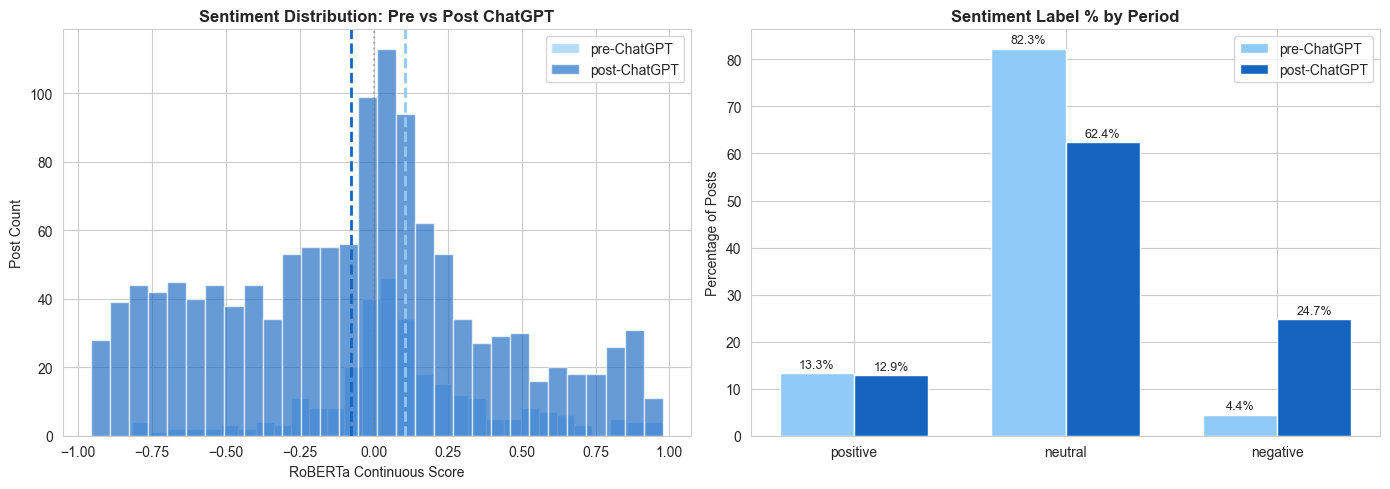

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# distribution comparison
ax = axes[0]
ax.hist(pre['roberta_continuous'],  bins=30, alpha=0.65, color=COLORS['pre'],  label='pre-ChatGPT')
ax.hist(post['roberta_continuous'], bins=30, alpha=0.65, color=COLORS['post'], label='post-ChatGPT')
ax.axvline(pre['roberta_continuous'].mean(),  color=COLORS['pre'],  linestyle='--', linewidth=2)
ax.axvline(post['roberta_continuous'].mean(), color=COLORS['post'], linestyle='--', linewidth=2)
ax.axvline(0, color='gray', linestyle=':', alpha=0.5)
ax.set_title('Sentiment Distribution: Pre vs Post ChatGPT', fontsize=12, fontweight='bold')
ax.set_xlabel('RoBERTa Continuous Score')
ax.set_ylabel('Post Count')
ax.legend()

# label breakdown side by side
ax = axes[1]
label_order = ['positive', 'neutral', 'negative']
pre_pcts  = [(pre['roberta_label']  == l).mean()*100 for l in label_order]
post_pcts = [(post['roberta_label'] == l).mean()*100 for l in label_order]
x = np.arange(len(label_order))
w = 0.35
bars1 = ax.bar(x - w/2, pre_pcts,  w, color=COLORS['pre'],  label='pre-ChatGPT',  edgecolor='white')
bars2 = ax.bar(x + w/2, post_pcts, w, color=COLORS['post'], label='post-ChatGPT', edgecolor='white')
for bars in [bars1, bars2]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels(label_order)
ax.set_title('Sentiment Label % by Period', fontsize=12, fontweight='bold')
ax.set_ylabel('Percentage of Posts')
ax.legend()

plt.tight_layout()
plt.savefig('../../reports/reddit_reports/pre_post_sentiment.png', dpi=150, bbox_inches='tight')
plt.show()

## Monthly Sentiment Trend
months with fewer than 10 posts are shown in grey and should be interpreted with caution. pre-2022 is sparse because there was much less reddit discussion about AI and wikipedia before chatgpt launched.

In [13]:
monthly = aggregate_sentiment_by_month(df, date_col='date')

print(f'total months: {len(monthly)}')
print()
print('monthly data:')
print(monthly[['month','post_count','roberta_continuous_mean','positive_pct','negative_pct']].to_string(index=False))


total months: 75

monthly data:
     month  post_count  roberta_continuous_mean  positive_pct  negative_pct
2020-01-01           2                -0.020947      0.000000      0.000000
2020-02-01          11                 0.154559     18.181818      9.090909
2020-03-01          10                -0.002043      0.000000      0.000000
2020-04-01           6                 0.094375     16.666667      0.000000
2020-05-01           9                -0.039154      0.000000      0.000000
2020-06-01           8                -0.071748     12.500000     12.500000
2020-07-01          12                 0.220945     33.333333      8.333333
2020-08-01          12                 0.146580      8.333333      0.000000
2020-09-01           8                 0.022708     12.500000     12.500000
2020-10-01          11                 0.105283     27.272727     18.181818
2020-11-01          11                 0.200005     18.181818      0.000000
2020-12-01           7                 0.381314     57.1

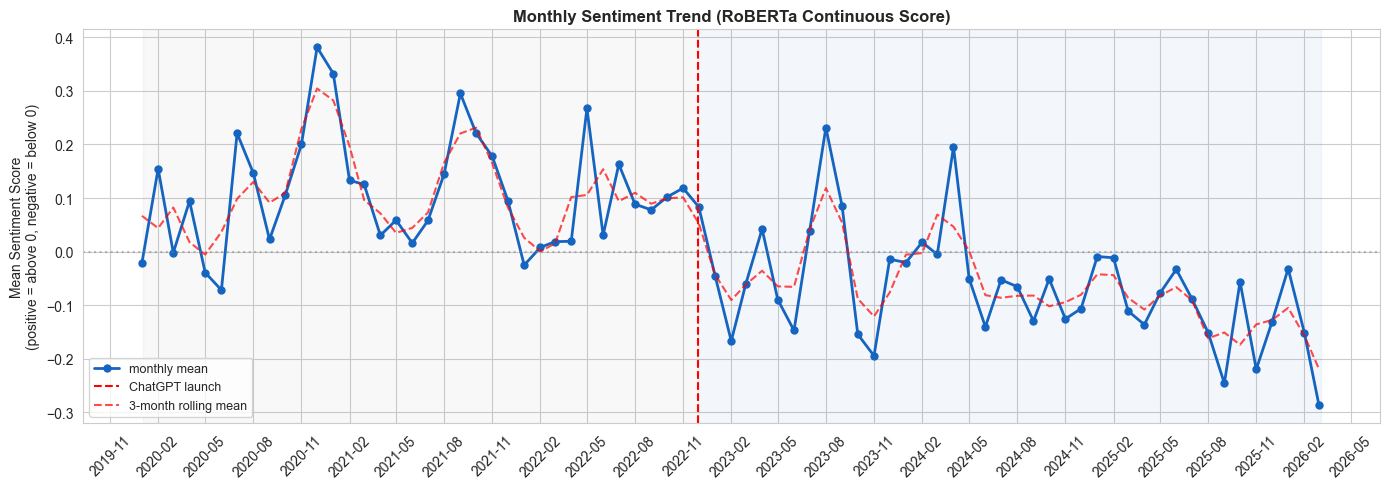

In [14]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(monthly['month'], monthly['roberta_continuous_mean'],
        color='#1565C0', linewidth=2, marker='o', markersize=5, label='monthly mean')

# shade by pre/post
ax.axvspan(df['date'].min(), CHATGPT_LAUNCH, alpha=0.05, color='gray')
ax.axvspan(CHATGPT_LAUNCH, df['date'].max(), alpha=0.05, color='#1565C0')
ax.axvline(CHATGPT_LAUNCH, color='red', linestyle='--', linewidth=1.5, label='ChatGPT launch')
ax.axhline(0, color='gray', linestyle=':', alpha=0.5)

# rolling mean
monthly_sorted = monthly.sort_values('month')
if len(monthly_sorted) >= 3:
    roll = monthly_sorted['roberta_continuous_mean'].rolling(3, center=True, min_periods=2).mean()
    ax.plot(monthly_sorted['month'], roll, color='red', linewidth=1.5,
            linestyle='--', alpha=0.7, label='3-month rolling mean')

ax.set_title('Monthly Sentiment Trend (RoBERTa Continuous Score)', fontsize=12, fontweight='bold')
ax.set_ylabel('Mean Sentiment Score\n(positive = above 0, negative = below 0)')
ax.legend(loc='lower left', fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))

plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../../reports/reddit_reports/monthly_sentiment_trend.png', dpi=150, bbox_inches='tight')
plt.show()


## Subreddit Sentiment Comparison
each subreddit represents a different community with different priors. r/wikipedia users are editors and enthusiasts and may react differently to AI than r/ChatGPT users who are early adopters.

In [15]:
sub_stats = df.groupby('subreddit').agg(
    n_posts=('roberta_label', 'count'),
    roberta_mean=('roberta_continuous', 'mean'),
    vader_mean=('vader_compound', 'mean'),
    positive_pct=('roberta_label', lambda x: (x=='positive').mean()*100),
    negative_pct=('roberta_label', lambda x: (x=='negative').mean()*100),
    neutral_pct=('roberta_label',  lambda x: (x=='neutral').mean()*100),
    avg_confidence=('roberta_score', 'mean')
).round(3)
sub_stats = sub_stats.sort_values('roberta_mean')
print(sub_stats.to_string())

                 n_posts  roberta_mean  vader_mean  positive_pct  negative_pct  neutral_pct  avg_confidence
subreddit                                                                                                  
technology            64        -0.188      -0.101         6.250        29.688       64.062           0.711
ChatGPT              450        -0.182       0.271        10.889        37.556       51.556           0.717
wikipedia            205        -0.085       0.221        11.707        22.439       65.854           0.728
OpenAI               177        -0.047       0.396        15.819        21.469       62.712           0.724
singularity          240         0.044       0.483        17.917        15.417       66.667           0.718
artificial           162         0.075       0.511        17.901        10.494       71.605           0.726
MachineLearning      293         0.094       0.653         9.898         2.730       87.372           0.777


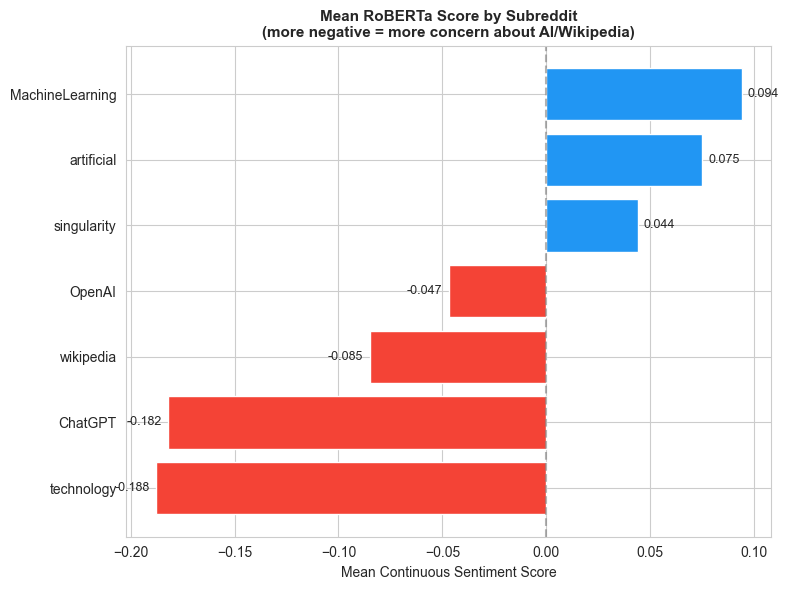

In [21]:
fig, ax = plt.subplots(figsize=(8, 6))

# mean sentiment by subreddit
colors = ['#F44336' if v < 0 else '#2196F3' for v in sub_stats['roberta_mean']]
bars = ax.barh(sub_stats.index, sub_stats['roberta_mean'], color=colors, edgecolor='white', linewidth=1)
ax.axvline(0, color='gray', linestyle='--', alpha=0.6)
for bar, val in zip(bars, sub_stats['roberta_mean']):
    ax.text(val + (0.003 if val >= 0 else -0.003),
            bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', ha='left' if val >= 0 else 'right', fontsize=9)
ax.set_title('Mean RoBERTa Score by Subreddit\n(more negative = more concern about AI/Wikipedia)', fontsize=11, fontweight='bold')
ax.set_xlabel('Mean Continuous Sentiment Score')

plt.tight_layout()
plt.savefig('../../reports/reddit_reports/subreddit_sentiment.png', dpi=150, bbox_inches='tight')
plt.show()


In [22]:
# pairwise Mann-Whitney U tests between subreddits
from itertools import combinations

subreddits = df['subreddit'].unique()
print('pairwise Mann-Whitney U tests (roberta_continuous):')
print(f'{"subreddit A":<20} {"subreddit B":<20} {"mean A":>8} {"mean B":>8} {"p-value":>10} {"significant":>12}')
print('-' * 80)
for a, b in combinations(sorted(subreddits), 2):
    scores_a = df[df['subreddit']==a]['roberta_continuous']
    scores_b = df[df['subreddit']==b]['roberta_continuous']
    _, p = stats.mannwhitneyu(scores_a, scores_b, alternative='two-sided')
    sig = 'YES *' if p < 0.05 else 'no'
    print(f'{a:<20} {b:<20} {scores_a.mean():>8.3f} {scores_b.mean():>8.3f} {p:>10.4f} {sig:>12}')

pairwise Mann-Whitney U tests (roberta_continuous):
subreddit A          subreddit B            mean A   mean B    p-value  significant
--------------------------------------------------------------------------------
ChatGPT              MachineLearning        -0.182    0.094     0.0000        YES *
ChatGPT              OpenAI                 -0.182   -0.047     0.0010        YES *
ChatGPT              artificial             -0.182    0.075     0.0000        YES *
ChatGPT              singularity            -0.182    0.044     0.0000        YES *
ChatGPT              technology             -0.182   -0.188     0.8562           no
ChatGPT              wikipedia              -0.182   -0.085     0.0070        YES *
MachineLearning      OpenAI                  0.094   -0.047     0.0007        YES *
MachineLearning      artificial              0.094    0.075     0.9961           no
MachineLearning      singularity             0.094    0.044     0.4388           no
MachineLearning      techno

## Sentiment vs Engagement
does sentiment predict how many upvotes or comments a post gets? negativity bias is well documented in social media research. we use log(score+1) because scores are heavily right-skewed.

In [30]:
df['log_score']    = np.log1p(df['score'])
df['log_comments'] = np.log1p(df['num_comments'])

corr_cols = ['roberta_continuous', 'roberta_numeric', 'vader_compound']
eng_cols  = ['log_score', 'log_comments']

print('pearson correlation: sentiment vs engagement')
print(f'{"metric":<25} {"log_score":>12} {"log_comments":>14}')
print('-' * 55)
for c in corr_cols:
    r_score, p_score    = stats.pearsonr(df[c], df['log_score'])
    r_comm,  p_comm     = stats.pearsonr(df[c], df['log_comments'])
    print(f'{c:<25} {r_score:>8.3f} (p={p_score:.3f})  {r_comm:>8.3f} (p={p_comm:.3f})')

pearson correlation: sentiment vs engagement
metric                       log_score   log_comments
-------------------------------------------------------
roberta_continuous           0.014 (p=0.578)    -0.183 (p=0.000)
roberta_numeric              0.019 (p=0.453)    -0.151 (p=0.000)
vader_compound              -0.115 (p=0.000)    -0.125 (p=0.000)


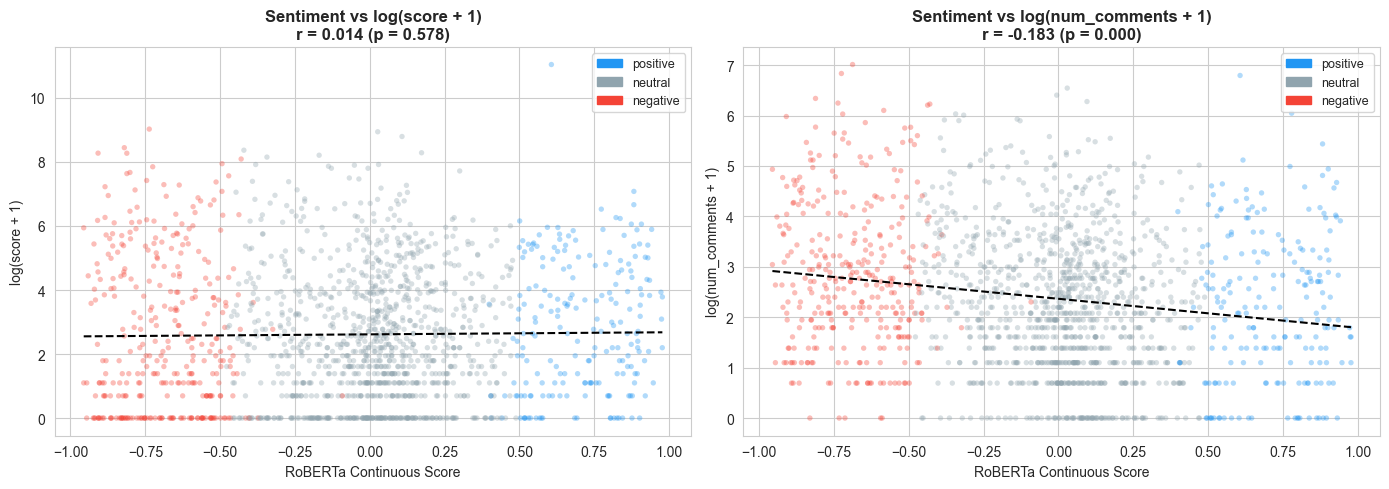

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (y_col, y_label) in zip(axes, [
    ('log_score',    'log(score + 1)'),
    ('log_comments', 'log(num_comments + 1)')
]):
    colors = [COLORS[l] for l in df['roberta_label']]
    ax.scatter(df['roberta_continuous'], df[y_col],
               c=colors, alpha=0.35, s=15, linewidths=0)
    # regression line
    m, b = np.polyfit(df['roberta_continuous'], df[y_col], 1)
    x_line = np.linspace(df['roberta_continuous'].min(), df['roberta_continuous'].max(), 100)
    ax.plot(x_line, m*x_line + b, color='black', linewidth=1.5, linestyle='--')
    r, p = stats.pearsonr(df['roberta_continuous'], df[y_col])
    ax.set_title(f'Sentiment vs {y_label}\nr = {r:.3f} (p = {p:.3f})', fontsize=12, fontweight='bold')
    ax.set_xlabel('RoBERTa Continuous Score')
    ax.set_ylabel(y_label)
    # legend
    handles = [mpatches.Patch(color=COLORS[l], label=l) for l in ['positive','neutral','negative']]
    ax.legend(handles=handles, fontsize=9)

plt.tight_layout()
plt.savefig('../../reports/reddit_reports/sentiment_vs_engagement.png', dpi=150, bbox_inches='tight')
plt.show()

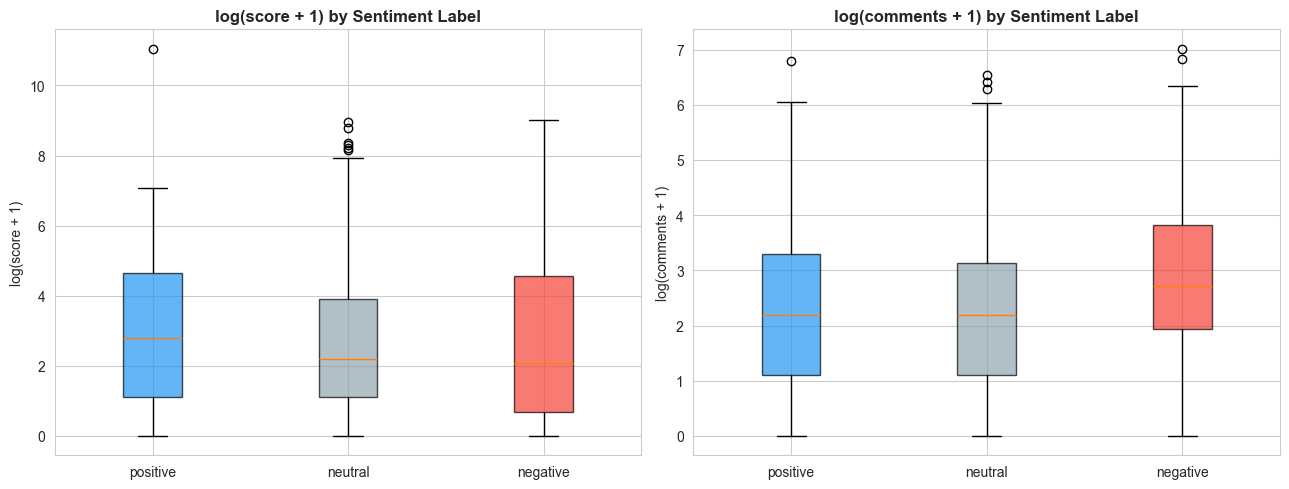

In [33]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
labels = ['positive', 'neutral', 'negative']

for ax, col, title in [(ax1, 'log_score', 'log(score + 1)'), (ax2, 'log_comments', 'log(comments + 1)')]:
    data = [df[df['roberta_label'] == l][col].values for l in labels]
    bp = ax.boxplot(data, patch_artist=True, labels=labels)
    for patch, l in zip(bp['boxes'], labels):
        patch.set_facecolor(COLORS[l])
        patch.set_alpha(0.7)
    ax.set_title(f'{title} by Sentiment Label', fontsize=12, fontweight='bold')
    ax.set_ylabel(title)

plt.tight_layout()
plt.savefig('../../reports/reddit_reports/engagement_by_label.png', dpi=150, bbox_inches='tight')
plt.show()


In [34]:
# full post-level dataset with all sentiment columns
output_cols = [
    'subreddit', 'title', 'text', 'score', 'date', 'num_comments',
    'url', 'permalink', 'id', 'period', 'has_body',
    'combined_text',
    'vader_compound', 'vader_pos', 'vader_neg', 'vader_neu', 'vader_label',
    'roberta_label', 'roberta_score', 'roberta_numeric', 'roberta_continuous',
    'roberta_pos', 'roberta_neu', 'roberta_neg',
    'high_confidence', 'vader_roberta_agree', 'disagreement_type',
    'log_score', 'log_comments'
]
output_cols = [c for c in output_cols if c in df.columns]

df[output_cols].to_csv(
    '../../data/processed/reddit_processed/reddit_with_sentiment.csv',
    index=False, encoding='utf-8-sig'
)
print(f'saved {len(df)} posts to reddit_with_sentiment.csv')

# monthly aggregated data
monthly.to_csv(
    '../../data/processed/reddit_processed/monthly_sentiment.csv',
    index=False, encoding='utf-8-sig'
)
print(f'saved {len(monthly)} months to monthly_sentiment.csv')

saved 1591 posts to reddit_with_sentiment.csv
saved 75 months to monthly_sentiment.csv


In [36]:
# sentiment analysis summary
print(f'total posts analysed: {len(df)}')
print()
print('roberta label distribution:')
for label, count in df['roberta_label'].value_counts().items():
    print(f'  {label}: {count} ({count/len(df)*100:.1f}%)')
print()
print(f'mean roberta continuous score: {df["roberta_continuous"].mean():.4f}')
print(f'pre-ChatGPT mean:  {pre["roberta_continuous"].mean():.4f}')
print(f'post-ChatGPT mean: {post["roberta_continuous"].mean():.4f}')
print()
print(f'statistical test: p={mw_p:.4f}, Cohen\'s d={cohens_d:.3f}')
print(f'vader/roberta agreement rate: {df["vader_roberta_agree"].mean()*100:.1f}%')
print(f'high-confidence predictions: {df["high_confidence"].mean()*100:.1f}%')

total posts analysed: 1591

roberta label distribution:
  neutral: 1051 (66.1%)
  negative: 334 (21.0%)
  positive: 206 (12.9%)

mean roberta continuous score: -0.0435
pre-ChatGPT mean:  0.1061
post-ChatGPT mean: -0.0772

statistical test: p=0.0000, Cohen's d=-0.460
vader/roberta agreement rate: 33.8%
high-confidence predictions: 70.6%
